# Banana Problem :
- ANIRUDDHA K S
- PES1UG23AM905
- AIML-A Section
- 20-03-2026
- **Task 1**: Vanilla Gradient Saliency Map for banana class
- **Task 2**: Activation Maximization for banana neuron in ResNet18



In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn.functional as F
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Input image path
image_path = "image.jpg"
if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {image_path}. Put image.jpg in notebook folder.")

# Load pretrained ResNet18
weights = ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights).to(device).eval()

# ImageNet categories and banana class index
categories = weights.meta["categories"]
banana_class_idx = categories.index("banana")
print("Banana class index:", banana_class_idx)

# Transform from model weights
preprocess = weights.transforms()

def denormalize(img_tensor):
    # Reverse normalization for display
    mean = torch.tensor([0.485, 0.456, 0.406], device=img_tensor.device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=img_tensor.device).view(1, 3, 1, 1)
    out = img_tensor * std + mean
    return out.clamp(0, 1)

Using device: cpu
Banana class index: 954


Top prediction: banana (0.9993)
Banana probability: 0.9993


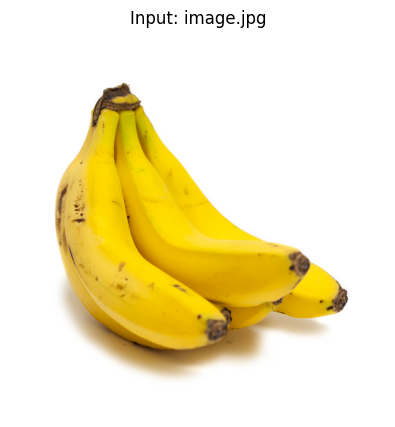

In [7]:
# Load and preview input image
pil_img = Image.open(image_path).convert("RGB")
input_tensor = preprocess(pil_img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)
    probs = F.softmax(logits, dim=1)
    top_prob, top_idx = probs.max(dim=1)

top_class_name = categories[top_idx.item()]
banana_prob = probs[0, banana_class_idx].item()

print(f"Top prediction: {top_class_name} ({top_prob.item():.4f})")
print(f"Banana probability: {banana_prob:.4f}")

plt.figure(figsize=(5, 5))
plt.imshow(pil_img)
plt.title("Input: image.jpg")
plt.axis("off")
plt.show()

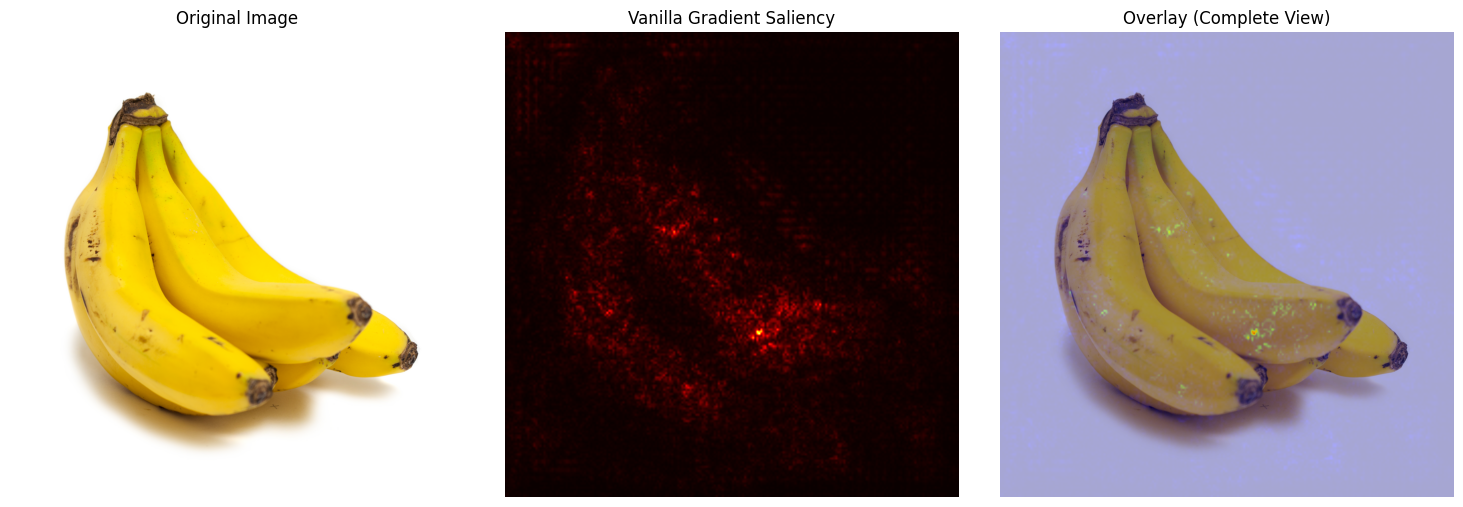

Task 1 interpretation:
- Check if edges/contours of banana are highlighted.
- Some noisy background edges are expected for vanilla gradients.


In [8]:
# Task 1: Vanilla Gradient Saliency Map for banana class
x = input_tensor.clone().detach().requires_grad_(True)
model.zero_grad(set_to_none=True)

scores = model(x)
banana_score = scores[0, banana_class_idx]
banana_score.backward()

# Saliency: max absolute gradient across RGB channels
grads = x.grad.detach().abs()
saliency = grads.max(dim=1)[0].squeeze().cpu().numpy()
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

orig = np.array(pil_img)

# Resize saliency to original image size so overlay is perfectly aligned and fully visible
saliency_resized = np.array(
    Image.fromarray((saliency * 255).astype(np.uint8)).resize(
        (orig.shape[1], orig.shape[0]),
        resample=Image.BILINEAR,
    )
).astype(np.float32) / 255.0

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(orig)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(saliency_resized, cmap="hot")
plt.title("Vanilla Gradient Saliency")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(orig)
plt.imshow(saliency_resized, cmap="jet", alpha=0.35)
plt.title("Overlay (Complete View)")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Task 1 interpretation:")
print("- Check if edges/contours of banana are highlighted.")
print("- Some noisy background edges are expected for vanilla gradients.")

Step 040/220, banana score: 119.7977
Step 080/220, banana score: 169.6316
Step 120/220, banana score: 193.7108
Step 160/220, banana score: 211.1978
Step 200/220, banana score: 224.2789


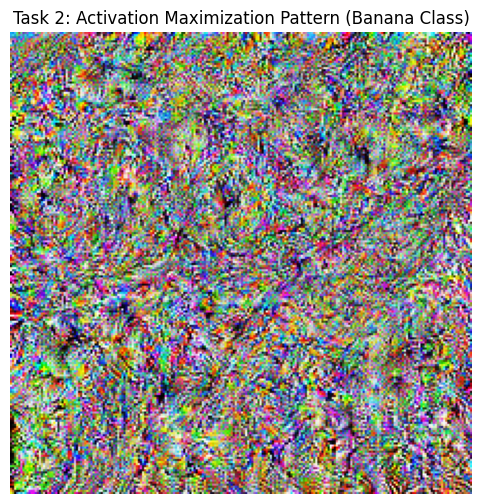

Task 2 interpretation:
- You should see curved/yellow-ish textures or banana-like patterns.
- If noisy, increase TV/L2 regularization or steps gradually.


In [9]:
# Task 2: Activation Maximization for banana neuron
# Start from random noise and optimize input image via gradient ascent
steps = 220
lr = 0.08
l2_lambda = 1e-4
tv_lambda = 1e-5

# Input shape for ResNet18 weights transform is 224x224
x_opt = torch.randn(1, 3, 224, 224, device=device, requires_grad=True)
optimizer = torch.optim.Adam([x_opt], lr=lr)

def total_variation(x):
    tv_h = (x[:, :, 1:, :] - x[:, :, :-1, :]).pow(2).mean()
    tv_w = (x[:, :, :, 1:] - x[:, :, :, :-1]).pow(2).mean()
    return tv_h + tv_w

mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

for step in range(steps):
    optimizer.zero_grad(set_to_none=True)

    x_clamped = torch.sigmoid(x_opt)
    x_norm = (x_clamped - mean) / std

    out = model(x_norm)
    banana_obj = out[0, banana_class_idx]

    loss = -banana_obj + l2_lambda * (x_clamped.pow(2).mean()) + tv_lambda * total_variation(x_clamped)
    loss.backward()
    optimizer.step()

    if (step + 1) % 40 == 0:
        print(f"Step {step+1:03d}/{steps}, banana score: {banana_obj.item():.4f}")

generated = torch.sigmoid(x_opt).detach()
generated_np = generated.squeeze(0).permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(np.clip(generated_np, 0, 1))
plt.title("Task 2: Activation Maximization Pattern (Banana Class)")
plt.axis("off")
plt.show()

print("Task 2 interpretation:")
print("- You should see curved/yellow-ish textures or banana-like patterns.")
print("- If noisy, increase TV/L2 regularization or steps gradually.")